In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
from pathlib import Path

DATA_DIR = Path("./car_color_dataset/train")
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

LR_HEAD = 1e-3
LR_FINETUNE = 1e-4
LR_SCRATCH = 1e-3

WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
FREEZE_EPOCHS = 3

In [4]:
assert DATA_DIR.exists(), f"Dataset path not found: {DATA_DIR}"

all_classes = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
print("Classes:", all_classes)
print("Num classes:", len(all_classes))

Classes: ['Black', 'Blue', 'Brown', 'Cyan', 'Green', 'Grey', 'Orange', 'Red', 'Violet', 'White', 'Yellow']
Num classes: 11


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [6]:
full_dataset_for_stats = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset_for_stats.classes
class_to_idx = full_dataset_for_stats.class_to_idx

print("Class names:", class_names)
print("Class to idx:", class_to_idx)
print("Total images:", len(full_dataset_for_stats))

Class names: ['Black', 'Blue', 'Brown', 'Cyan', 'Green', 'Grey', 'Orange', 'Red', 'Violet', 'White', 'Yellow']
Class to idx: {'Black': 0, 'Blue': 1, 'Brown': 2, 'Cyan': 3, 'Green': 4, 'Grey': 5, 'Orange': 6, 'Red': 7, 'Violet': 8, 'White': 9, 'Yellow': 10}
Total images: 3802


,class,count
0,Black,402
1,Blue,284
2,Brown,150
3,Cyan,267
4,Green,269
5,Grey,333
6,Orange,557
7,Red,526
8,Violet,163
9,White,411


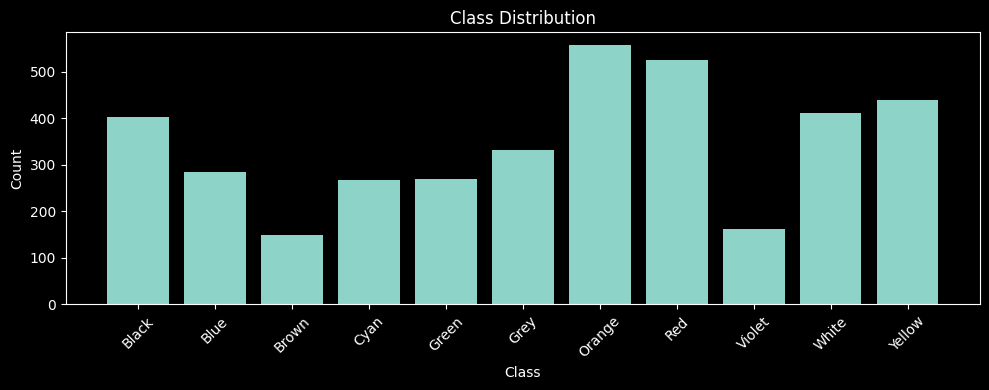

In [7]:
from collections import Counter

targets = [label for _, label in full_dataset_for_stats.samples]
counts = Counter(targets)

dist_df = pd.DataFrame({
    "class": [class_names[i] for i in counts.keys()],
    "count": [counts[i] for i in counts.keys()]
}).sort_values("class")

display(dist_df)

plt.figure(figsize=(10, 4))
plt.bar(dist_df["class"], dist_df["count"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
indices = list(range(len(full_dataset_for_stats)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))
print("Total:", len(train_idx) + len(val_idx) + len(test_idx))

Train: 2661
Val: 570
Test: 571
Total: 3802


In [9]:
base_dataset_train = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
base_dataset_eval = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

train_dataset = Subset(base_dataset_train, train_idx)
val_dataset = Subset(base_dataset_eval, val_idx)
test_dataset = Subset(base_dataset_eval, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 84
Val batches: 18
Test batches: 18


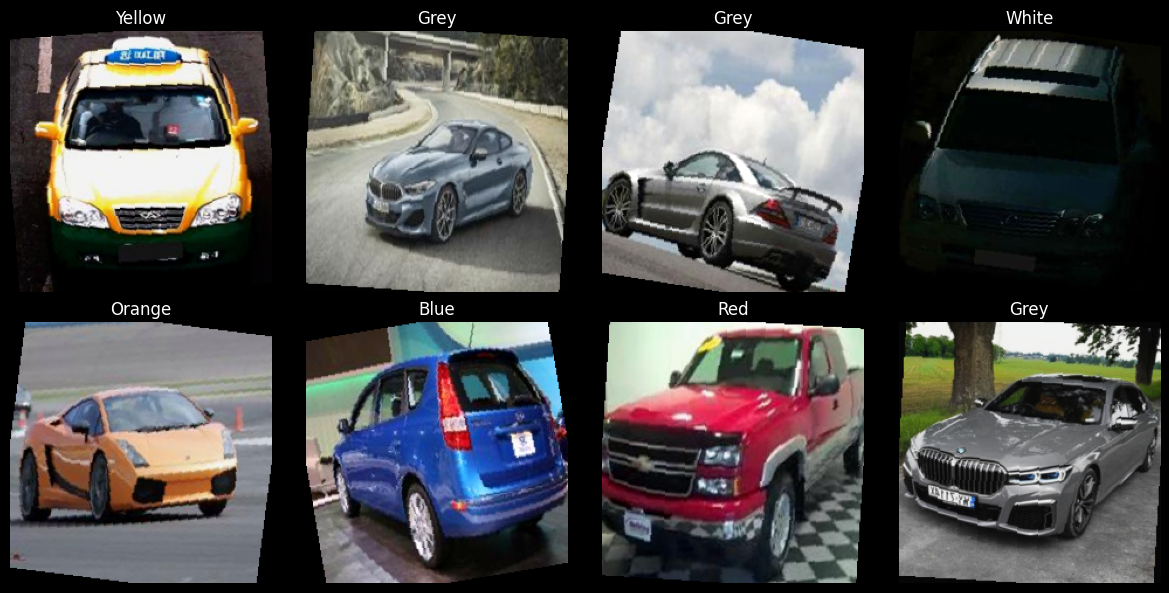

In [10]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
class CustomCarColorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
#Model A : ImageNet pretrained

def build_model_a_imagenet(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [13]:
import timm

def build_model_b_other_pretrained(num_classes):
    model = timm.create_model(
        "vit_base_patch16_clip_224.laion400m_e32",
        pretrained=True,
        num_classes=num_classes
    )
    return model

C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
num_classes = len(class_names)

model_a = build_model_a_imagenet(num_classes)
model_b = build_model_b_other_pretrained(num_classes)
model_c = CustomCarColorCNN(num_classes)

print("Model A:", type(model_a).__name__)
print("Model B:", type(model_b).__name__)
print("Model C:", type(model_c).__name__)

Model A: ResNet
Model B: VisionTransformer
Model C: CustomCarColorCNN


In [15]:
def freeze_resnet18_except_fc(model):
    for name, param in model.named_parameters():
        if name.startswith("fc"):
            param.requires_grad = True
        else:
            param.requires_grad = False


def freeze_vit_except_head(model):
    for name, param in model.named_parameters():
        if name.startswith("head"):
            param.requires_grad = True
        else:
            param.requires_grad = False

def freeze_model_except_head(model, head_keywords=("fc", "classifier", "head")):
    for name, param in model.named_parameters():
        if any(key in name for key in head_keywords):
            param.requires_grad = True
        else:
            param.requires_grad = False

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [16]:
model_a = build_model_a_imagenet(num_classes)
model_b = build_model_b_other_pretrained(num_classes)
model_c = CustomCarColorCNN(num_classes)

freeze_resnet18_except_fc(model_a)
freeze_vit_except_head(model_b)

for model_name, model in [("Model A", model_a), ("Model B", model_b), ("Model C", model_c)]:
    total, trainable = count_trainable_params(model)
    print(f"{model_name}: total={total:,}, trainable={trainable:,}")

Model A: total=11,182,155, trainable=5,643
Model B: total=85,807,883, trainable=8,459
Model C: total=391,243, trainable=391,243


In [17]:
def compute_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(dim=1)
        y_true_all.extend(labels.cpu().numpy())
        y_pred_all.extend(preds.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1 = compute_macro_f1(y_true_all, y_pred_all)
    return epoch_loss, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(dim=1)
        y_true_all.extend(labels.cpu().numpy())
        y_pred_all.extend(preds.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1 = compute_macro_f1(y_true_all, y_pred_all)
    return epoch_loss, epoch_f1, y_true_all, y_pred_all

In [18]:
def fit_model(model, train_loader, val_loader, epochs, lr, weight_decay, device, optimizer_name="adamw"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adamw":
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )
    else:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": []
    }

    best_val_f1 = -1
    best_state = None

    for epoch in range(epochs):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train F1_macro: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val F1_macro: {val_f1:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [19]:
def plot_history(history, title="Training History"):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_f1"], label="Train F1_macro")
    plt.plot(epochs_range, history["val_f1"], label="Val F1_macro")
    plt.xlabel("Epoch")
    plt.ylabel("F1_macro")
    plt.title(f"{title} - F1_macro")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [20]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.keys():
        merged[k] = h1[k] + h2[k]
    return merged

Training Model A - Stage 1 (head only)
Epoch [1/3] | Train Loss: 1.5530 | Train F1_macro: 0.4750 | Val Loss: 1.0182 | Val F1_macro: 0.7454
Epoch [2/3] | Train Loss: 0.8092 | Train F1_macro: 0.7665 | Val Loss: 0.7162 | Val F1_macro: 0.8232
Epoch [3/3] | Train Loss: 0.6037 | Train F1_macro: 0.8151 | Val Loss: 0.5871 | Val F1_macro: 0.8414
Training Model A - Stage 2 (fine-tuning all layers)
Epoch [1/12] | Train Loss: 0.2353 | Train F1_macro: 0.9176 | Val Loss: 0.1182 | Val F1_macro: 0.9511
Epoch [2/12] | Train Loss: 0.0850 | Train F1_macro: 0.9743 | Val Loss: 0.1250 | Val F1_macro: 0.9587
Epoch [3/12] | Train Loss: 0.0626 | Train F1_macro: 0.9803 | Val Loss: 0.1056 | Val F1_macro: 0.9602
Epoch [4/12] | Train Loss: 0.0511 | Train F1_macro: 0.9826 | Val Loss: 0.0823 | Val F1_macro: 0.9695
Epoch [5/12] | Train Loss: 0.0652 | Train F1_macro: 0.9704 | Val Loss: 0.0696 | Val F1_macro: 0.9622
Epoch [6/12] | Train Loss: 0.0495 | Train F1_macro: 0.9881 | Val Loss: 0.0687 | Val F1_macro: 0.9748
Epo

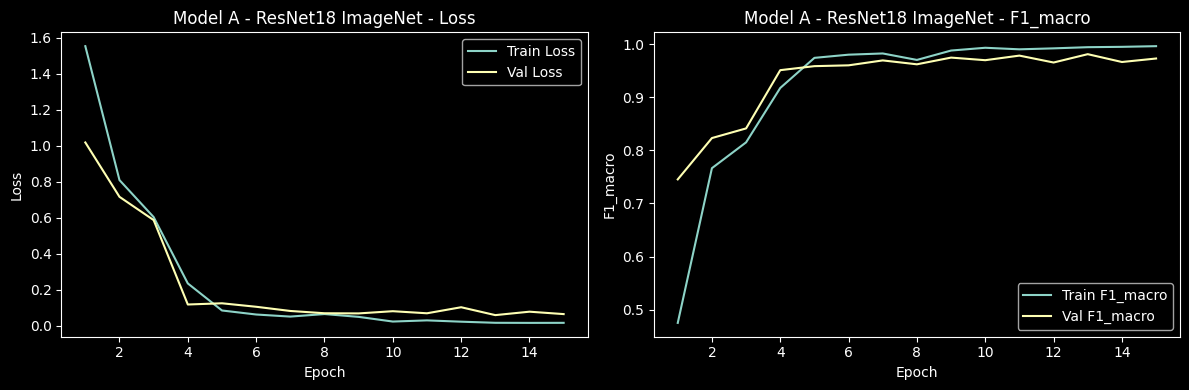

In [21]:
model_a = build_model_a_imagenet(num_classes)

# Stage 1: train head only
freeze_model_except_head(model_a)

print("Training Model A - Stage 1 (head only)")
model_a, history_a_stage1 = fit_model(
    model_a,
    train_loader,
    val_loader,
    epochs=FREEZE_EPOCHS,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
    device=device
)

# Stage 2: fine-tune all layers
unfreeze_all(model_a)

print("Training Model A - Stage 2 (fine-tuning all layers)")
model_a, history_a_stage2 = fit_model(
    model_a,
    train_loader,
    val_loader,
    epochs=EPOCHS - FREEZE_EPOCHS,
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY,
    device=device
)

history_a = merge_histories(history_a_stage1, history_a_stage2)
plot_history(history_a, title="Model A - ResNet18 ImageNet")

Training Model B - Stage 1 (head only)
Epoch [1/3] | Train Loss: 2.5518 | Train F1_macro: 0.0732 | Val Loss: 2.3818 | Val F1_macro: 0.0157
Epoch [2/3] | Train Loss: 2.5181 | Train F1_macro: 0.0759 | Val Loss: 2.4285 | Val F1_macro: 0.0184
Epoch [3/3] | Train Loss: 2.4338 | Train F1_macro: 0.0723 | Val Loss: 2.0744 | Val F1_macro: 0.0549
Training Model B - Stage 2 (fine-tuning all layers)
Epoch [1/8] | Train Loss: 2.2665 | Train F1_macro: 0.0928 | Val Loss: 2.0645 | Val F1_macro: 0.0721
Epoch [2/8] | Train Loss: 2.0122 | Train F1_macro: 0.1638 | Val Loss: 1.9430 | Val F1_macro: 0.1195
Epoch [3/8] | Train Loss: 1.8470 | Train F1_macro: 0.1945 | Val Loss: 1.7968 | Val F1_macro: 0.2188
Epoch [4/8] | Train Loss: 1.8066 | Train F1_macro: 0.2419 | Val Loss: 1.7429 | Val F1_macro: 0.2236
Epoch [5/8] | Train Loss: 1.6956 | Train F1_macro: 0.2615 | Val Loss: 1.6113 | Val F1_macro: 0.2630
Epoch [6/8] | Train Loss: 1.5864 | Train F1_macro: 0.3248 | Val Loss: 1.6084 | Val F1_macro: 0.3059
Epoch [7/

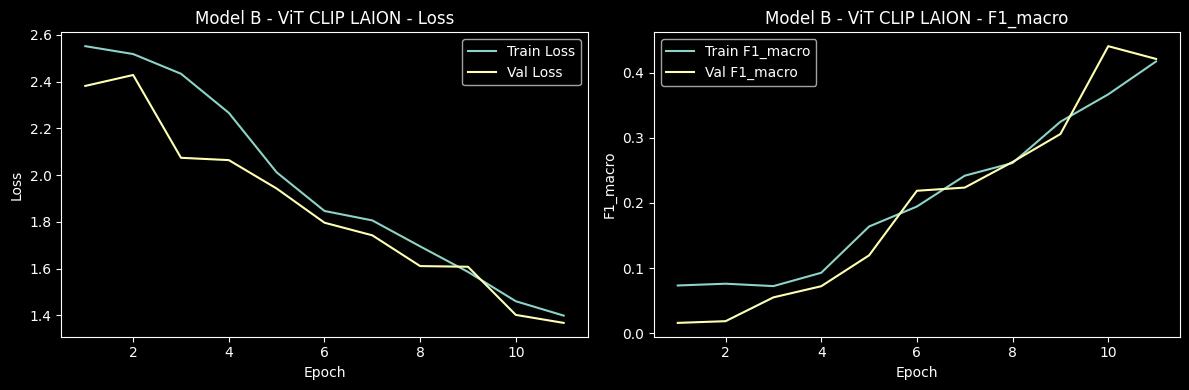

In [22]:
model_b = build_model_b_other_pretrained(num_classes)

# Stage 1: train head only
freeze_model_except_head(model_b)

print("Training Model B - Stage 1 (head only)")
model_b, history_b_stage1 = fit_model(
    model_b,
    train_loader,
    val_loader,
    epochs=3,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
    device=device
)

# Stage 2: fine-tune all layers
unfreeze_all(model_b)

print("Training Model B - Stage 2 (fine-tuning all layers)")
model_b, history_b_stage2 = fit_model(
    model_b,
    train_loader,
    val_loader,
    epochs=8,
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY,
    device=device
)

history_b = merge_histories(history_b_stage1, history_b_stage2)
plot_history(history_b, title="Model B - ViT CLIP LAION")

Training Model C - From Scratch
Epoch [1/15] | Train Loss: 1.8454 | Train F1_macro: 0.2249 | Val Loss: 1.4696 | Val F1_macro: 0.3209
Epoch [2/15] | Train Loss: 1.3922 | Train F1_macro: 0.4136 | Val Loss: 1.2942 | Val F1_macro: 0.4103
Epoch [3/15] | Train Loss: 1.1294 | Train F1_macro: 0.5419 | Val Loss: 0.9870 | Val F1_macro: 0.5662
Epoch [4/15] | Train Loss: 1.0130 | Train F1_macro: 0.6268 | Val Loss: 0.7793 | Val F1_macro: 0.7519
Epoch [5/15] | Train Loss: 0.8782 | Train F1_macro: 0.6913 | Val Loss: 0.7771 | Val F1_macro: 0.6917
Epoch [6/15] | Train Loss: 0.8260 | Train F1_macro: 0.7082 | Val Loss: 0.7690 | Val F1_macro: 0.6920
Epoch [7/15] | Train Loss: 0.7302 | Train F1_macro: 0.7379 | Val Loss: 0.5668 | Val F1_macro: 0.8087
Epoch [8/15] | Train Loss: 0.6809 | Train F1_macro: 0.7566 | Val Loss: 0.6045 | Val F1_macro: 0.7797
Epoch [9/15] | Train Loss: 0.7193 | Train F1_macro: 0.7529 | Val Loss: 0.5645 | Val F1_macro: 0.7910
Epoch [10/15] | Train Loss: 0.6480 | Train F1_macro: 0.7860

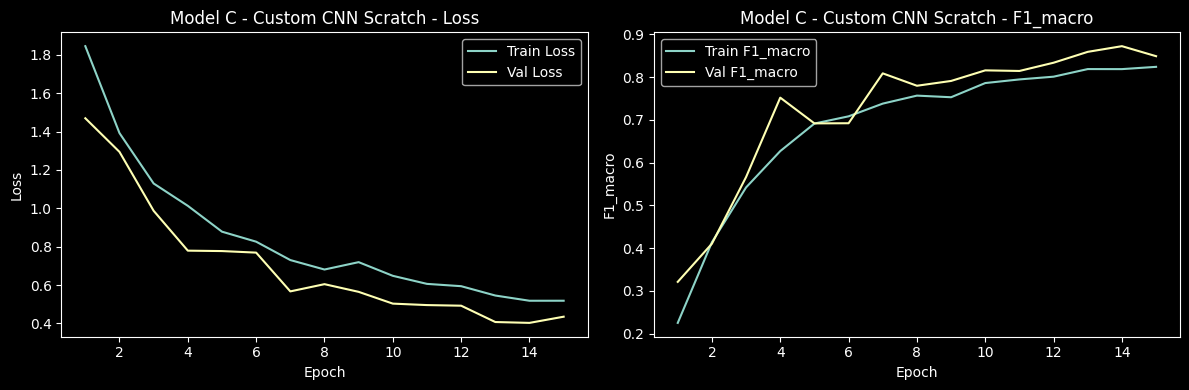

In [23]:
model_c = CustomCarColorCNN(num_classes)

print("Training Model C - From Scratch")
model_c, history_c = fit_model(
    model_c,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR_SCRATCH,
    weight_decay=WEIGHT_DECAY,
    device=device
)

plot_history(history_c, title="Model C - Custom CNN Scratch")

In [24]:
criterion = nn.CrossEntropyLoss()

results = {}

for model_name, model in {
    "Model_A_ImageNet": model_a,
    "Model_B_LAION": model_b,
    "Model_C_Scratch": model_c
}.items():
    test_loss, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    results[model_name] = {
        "test_loss": test_loss,
        "test_f1_macro": test_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

    print(f"{model_name}: Test Loss = {test_loss:.4f}, Test F1_macro = {test_f1:.4f}")

Model_A_ImageNet: Test Loss = 0.1594, Test F1_macro = 0.9442
Model_B_LAION: Test Loss = 1.4735, Test F1_macro = 0.3769
Model_C_Scratch: Test Loss = 0.5557, Test F1_macro = 0.8037


In [25]:
comparison_df = pd.DataFrame([
    {
        "model": model_name,
        "test_loss": result["test_loss"],
        "test_f1_macro": result["test_f1_macro"]
    }
    for model_name, result in results.items()
]).sort_values("test_f1_macro", ascending=False)

display(comparison_df)

,model,test_loss,test_f1_macro
0,Model_A_ImageNet,0.159356,0.944194
2,Model_C_Scratch,0.555705,0.803732
1,Model_B_LAION,1.473467,0.376918


In [26]:
for model_name, result in results.items():
    print("=" * 90)
    print(model_name)
    print(classification_report(
        result["y_true"],
        result["y_pred"],
        target_names=class_names,
        digits=4
    ))

Model_A_ImageNet
              precision    recall  f1-score   support

       Black     0.9577    0.9444    0.9510        72
        Blue     0.9615    1.0000    0.9804        50
       Brown     0.7647    0.8667    0.8125        15
        Cyan     1.0000    0.8500    0.9189        60
       Green     1.0000    0.9688    0.9841        32
        Grey     0.7857    0.9778    0.8713        45
      Orange     0.9605    0.9359    0.9481        78
         Red     0.9878    0.9759    0.9818        83
      Violet     1.0000    1.0000    1.0000        23
       White     0.9815    0.9636    0.9725        55
      Yellow     0.9655    0.9655    0.9655        58

    accuracy                         0.9510       571
   macro avg     0.9423    0.9499    0.9442       571
weighted avg     0.9558    0.9510    0.9517       571

Model_B_LAION
              precision    recall  f1-score   support

       Black     0.6557    0.5556    0.6015        72
        Blue     0.3438    0.4400    0.3860    

C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

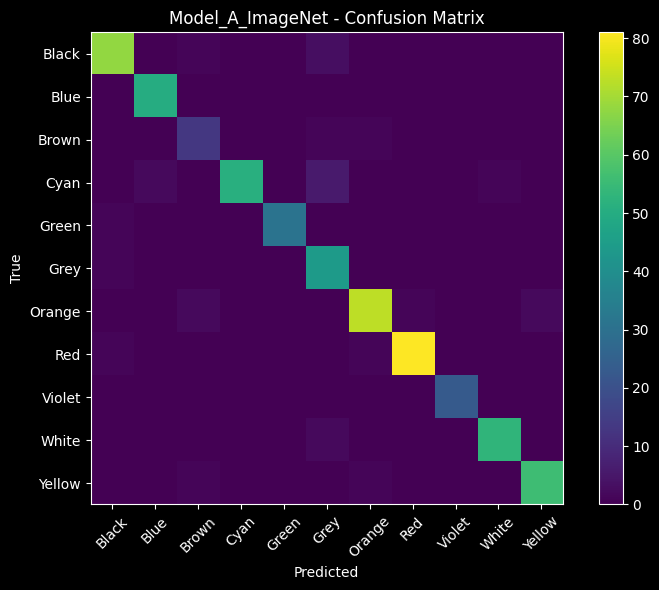

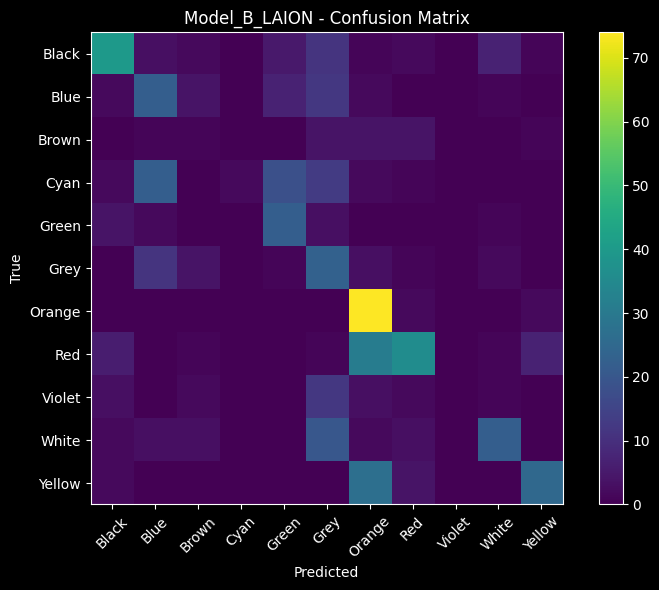

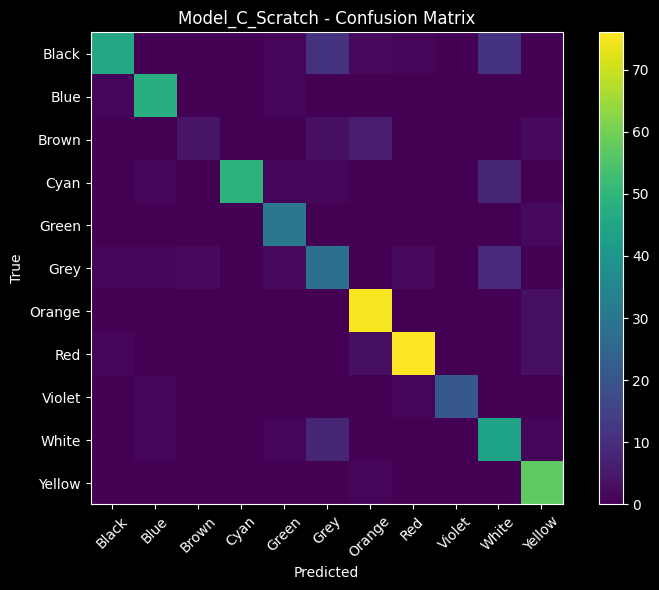

In [27]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

for model_name, result in results.items():
    plot_confusion_matrix(
        result["y_true"],
        result["y_pred"],
        class_names,
        title=f"{model_name} - Confusion Matrix"
    )

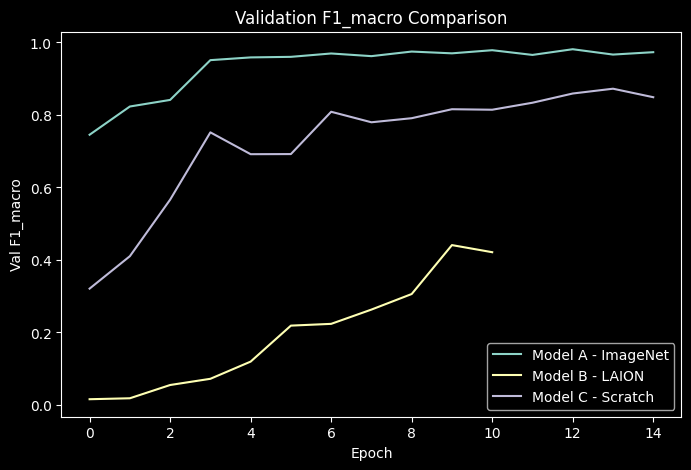

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history_a["val_f1"], label="Model A - ImageNet")
plt.plot(history_b["val_f1"], label="Model B - LAION")
plt.plot(history_c["val_f1"], label="Model C - Scratch")
plt.xlabel("Epoch")
plt.ylabel("Val F1_macro")
plt.title("Validation F1_macro Comparison")
plt.legend()
plt.show()

In [29]:
os.makedirs("saved_models_lab4", exist_ok=True)

torch.save(model_a.state_dict(), "saved_models_lab4/model_a_imagenet.pth")
torch.save(model_b.state_dict(), "saved_models_lab4/model_b_laion.pth")
torch.save(model_c.state_dict(), "saved_models_lab4/model_c_scratch.pth")

print("Models saved.")

Models saved.
